In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the os module for working with directories
import os

# Change the current working directory
os.chdir("/content/drive/MyDrive/Timi normal weight_Zhang")

# Print the current working directory to verify the change
print(os.getcwd())

/content/drive/MyDrive/Timi normal weight_Zhang


In [ ]:
#set working directory
setwd("/content/drive/MyDrive/Timi normal weight_Zhang")

# Installation and libraries

Installation and libraries

In [ ]:
# Code for overweight dataset
library(survival)
library(dplyr)
install.packages("doParallel")
library(doParallel)
library(foreach)
library(ggplot2)
install.packages("circlize")
library(circlize)
library(RColorBrewer)

# Install devtools from CRAN if not already installed.

if(!require(devtools)){

install.packages("devtools")

}

# Install TimiGP R package from GitHub:

# https://github.com/CSkylarL/TimiGP

devtools::install_github("CSkylarL/TimiGP")
library(TimiGP)
library(grid)
library(grDevices)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘foreach’, ‘iterators’


Loading required package: foreach

Loading required package: iterators

Loading required package: parallel

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘GlobalOptions’, ‘shape’


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(libr


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpXFbwNk/remotes5d84038f1bd/CSkylarL-TimiGP-9a527dd/DESCRIPTION’ ... OK
* preparing ‘TimiGP’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* looking to see if a ‘data/datalist’ file should be added
* building ‘TimiGP_1.3.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("gridExtra")
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




# Set up Data (Choose the gene TimiGp gene set)

In [ ]:
#manually edit event to binary 0 and 1 in excel and imprt the csv back: column name 1st vacant, 2nd event, 3rd: time, deleted all NA kept vacnat as cells
SKCM06rna <- read.csv("/content/drive/MyDrive/Timi normal weight_Zhang/processed_PDAC_normalweight_TPM.csv", check.names = FALSE)
SKCM06info <- read.csv("/content/drive/MyDrive/Timi normal weight_Zhang/normal_clin_edit.csv")
geneset <- read.csv("/content/drive/MyDrive/Timi normal weight_Zhang/CellType_Zheng2021_Tcell.csv")
#geneset <- read.csv("/content/drive/MyDrive/Timi_normal_weight_Bindeya/CellType_Bindea2013_cancer.csv") (Choose data set here)
#geneset <- read.csv("/content/drive/MyDrive/Timi normal weight_Zhang/CellType_Zheng2021_Tcell.csv")
#geneset <- read.csv("/content/drive/MyDrive/timigp normal weight_llm22/CellType_newman2015_LM22.csv")
marker <- unique(geneset$Gene)

In [ ]:
# Set the first column as row names and remove it from the data frame
SKCM06rna <- SKCM06rna[!is.na(SKCM06rna[,1]), ]
rownames(SKCM06rna) <- SKCM06rna[,1]
SKCM06rna <- SKCM06rna[,-1]

# Set the first column as row names and remove it from the data frame
SKCM06info <- SKCM06info[!is.na(SKCM06info[,1]), ]
rownames(SKCM06info) <- SKCM06info[,1]
SKCM06info <- SKCM06info[,-1]

head(SKCM06rna)
dim(SKCM06rna)

head(SKCM06info)
head(geneset)

,C3N-03211,C3N-01502,C3N-01998,C3N-04284,C3N-04126,C3N-00516,C3L-02112,C3N-01714,C3N-02589,C3N-02944,⋯,C3N-03086,C3L-03395,C3L-02890,C3N-03428,C3L-03628,C3N-03190,C3N-02573,C3N-03840,,.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>
A1BG,0.2785,0.2001,0.1559,0.1514,0.1915,0.2572,0.2144,0.1456,0.3192,0.4174,⋯,0.2817,0.3309,0.2732,0.2579,0.2447,0.0748,0.2965,0.1053,NA,NA
A1BG-AS1,0.8253,0.7545,0.6215,0.3753,0.9269,1.3133,1.1981,0.7645,1.2189,1.0366,⋯,1.1407,1.1373,1.5976,1.2461,1.0549,0.3370,0.9733,0.8735,NA,NA
A1CF,4.1081,2.2722,2.1600,9.2986,2.9842,0.9476,3.5717,1.4557,4.2975,4.8836,⋯,1.4859,4.0991,5.0064,0.9087,2.7982,2.8355,2.9923,2.6482,NA,NA
A2M,668.3472,487.8255,368.7986,151.4928,361.5145,304.1813,588.2325,458.3404,555.1797,456.5941,⋯,519.4755,427.3058,462.8180,338.2465,593.5605,415.3269,617.8451,488.5948,NA,NA
A2M-AS1,7.7772,5.6006,2.6145,1.8674,3.9837,5.2876,6.7108,2.6108,8.2742,4.7455,⋯,4.5218,2.9623,4.8678,14.7464,3.8331,1.4819,3.1872,3.8847,NA,NA
A2ML1,1.7122,0.2846,0.2455,0.1308,14.2795,23.3310,0.2824,0.2965,0.2279,30.1577,⋯,0.9314,0.2774,0.2952,0.2106,2.3127,0.5185,5.5579,9.7786,NA,NA


[1] 40894    53

,event,time
,<int>,<int>
C3N-04283,1,1
C3L-01052,1,743
C3N-01165,1,241
C3L-00625,1,1198
C3L-00401,1,1262
C3L-02610,1,190


,CellType,Gene,Dataset
,<chr>,<chr>,<chr>
1,CD8+Tn,LEF1,Zheng2021
2,CD8+Tn,TCF7,Zheng2021
3,CD8+Tn,KLF2,Zheng2021
4,CD8+Tn,TXK,Zheng2021
5,CD8+Tn,BACH2,Zheng2021
6,CD8+Tn,LTB,Zheng2021


In [ ]:
info <- TimiCheckEvent(SKCM06info)

rna <- TimiPrePropress(marker = marker, rna = SKCM06rna, cohort = rownames(info), log = TRUE, GMNorm=TRUE)

mps <- TimiGenePair(rna=rna, cont=FALSE)


# Run the TimiCOX function

res <- TimiCOX( mps = mps,

                info = info,

                p.adj = "fdr",

                parallel = T,

                core = 15)


0 individuals were filtered out due to NAs or time <= 0

0 markers with low expressions were filtered out

Generating marker pairs

The default is to capture logical relation

0 marker pairs were filtered out

70876 marker pairs were produced

Enable parallel computing.

------------- Calculating -------------

Please be patient.

The computation time may be increased if there are a larger number of cell type markers.

The direction of 37516 marker pairs were reversed



# Set P value or Q value cut offs

In [ ]:
# Extract the 'mps' and 'cox_res' objects from the 'res' result
mps <- res$mps
cox_res <- res$cox_res

# Count the number of marker pairs with Adjusted P-value (PV) less than 0.01
sum(cox_res$PV < 0.01)

# Calculate the percentage of significant marker pairs relative to the total number of marker pairs
round(sum(cox_res$PV < 0.01) / nrow(cox_res) * 100, 2)

# Set up a variable to define the condition for selecting marker pairs based on the Adjusted P-value
GPcondition <- "PV"

# Set up a variable to define the cutoff value for the Adjusted P-value
GPcutoff <- 0.01

[1] 3286

[1] 4.64

If P value is selected run this code other wise skip this code. Run to see top 1% & 5% genes from p=<0.01 markers

In [ ]:
# Sort cox_res by P-value (PV) in ascending order to select the top 5% and 1% of significant markers
top_5_percent_count <- ceiling(0.05 * nrow(cox_res))
top_1_percent_count <- ceiling(0.01 * nrow(cox_res))

top_5_percent_markers <- cox_res[order(cox_res$PV), ][1:top_5_percent_count, ]
top_1_percent_markers <- cox_res[order(cox_res$PV), ][1:top_1_percent_count, ]

# Calculate and print the number of markers for the top 5%
print(paste("Number of markers in the top 5%:", top_5_percent_count))

# Calculate and print the number of markers for the top 1%
print(paste("Number of markers in the top 1%:", top_1_percent_count))


[1] "Number of markers in the top 5%: 3544"
[1] "Number of markers in the top 1%: 709"


# Top 5% data

Run permutations for top 5% data

In [ ]:
GP <- rownames(top_5_percent_markers)[which(top_5_percent_markers[,GPcondition] < GPcutoff)]

background <- TimiBG(marker.pair = row.names(top_5_percent_markers))

cell_pair <- TimiCellPair(geneset = geneset, core = 8)

res <- TimiEnrich( gene = GP,

                   background = background,

                   geneset = cell_pair,

                   p.adj = "BH",

                   core = 15,

                   pair=TRUE)

# Count the number of marker pairs with an Adjusted P-value less than 0.05

sum(res$Adjust.P.Value < 0.01)

# Calculate the percentage of cell-cell interaction defined by the above condition and the cutoff

round(sum(res$Adjust.P.Value < 0.01)/nrow(res) * 100, 2) # Returns 11.69

# Set up a variable to define the condition for cell-cell interaction based on the Adjusted P-value.

CIcondition <- "Adjust.P.Value"

# Set up a variable to define the cutoff value for the Adjusted P-value.

CIcutoff <- 0.05

# CI represents Cell-cell Interaction

res <- TimiPermFDR( resdata = res,

                    geneset = geneset,

                    gene = GP,

                    background = background,

                    niter = 100,

                    core = 15)



7088 Background Pairs were generated from given 3544 pairs



[1] 341

[1] 21.86

--------------- Run 100 permutations. Please be patient ---------------

Permeutation#1: Different / Total markers: 923/926

Permeutation#2: Different / Total markers: 918/926

Permeutation#3: Different / Total markers: 920/926

Permeutation#4: Different / Total markers: 924/926

Permeutation#5: Different / Total markers: 924/926

Permeutation#6: Different / Total markers: 921/926

Permeutation#7: Different / Total markers: 923/926

Permeutation#8: Different / Total markers: 920/926

Permeutation#9: Different / Total markers: 924/926

Permeutation#10: Different / Total markers: 923/926

Permeutation#11: Different / Total markers: 924/926

Permeutation#12: Different / Total markers: 920/926

Permeutation#13: Different / Total markers: 923/926

Permeutation#14: Different / Total markers: 923/926

Permeutation#15: Different / Total markers: 922/926

Permeutation#16: Different / Total markers: 921/926

Permeutation#17: Different / Total markers: 924/926

Permeutation#18: Different / Total 

TimiDotPlot

In [ ]:
library(ggplot2)

# Function to create TimiDotplot in a specific format
save_timidotplot <- function(filename, width = 10, height = 8, res = 300,
                             resdata, select, condition, cutoff,
                             color_by = "Adjust.P.Value", color_limits = c(0, 0.01)) {
  # Open the appropriate device based on file extension
  switch(tools::file_ext(filename),
         "svg" = svg(filename, width = width, height = height),
         "tiff" = tiff(filename, width = width, height = height, units = "in", res = res),
         "pdf" = pdf(filename, width = width, height = height))

  # Create the TimiDotplot
  tryCatch({
    plot <- TimiDotplot(resdata = resdata,
                        select = select,
                        condition = condition,
                        cutoff = cutoff)

    # Modify the plot to set color and limits
    plot <- plot +
      scale_color_gradient(low = "blue", high = "red",
                           limits = color_limits,
                           oob = scales::squish) +
      labs(color = color_by)

    # Print the modified plot
    print(plot)

  }, error = function(e) {
    message("Error in TimiDotplot or plot modification: ", e$message)
  })

  # Close the device
  dev.off()
}

# Save in SVG format
save_timidotplot("timidotplot_Top5percent.svg",
                 resdata = res,
                 select = c(1:10),
                 condition = CIcondition,
                 cutoff = CIcutoff)

# Save in TIFF format
save_timidotplot("timidotplot_Top5percent.tiff",
                 resdata = res,
                 select = c(1:10),
                 condition = CIcondition,
                 cutoff = CIcutoff)

# Save in PDF format
save_timidotplot("timidotplot_Top5percent.pdf",
                 resdata = res,
                 select = c(1:10),
                 condition = CIcondition,
                 cutoff = CIcutoff)

The color for dotplot is Adjust.P.Value

The color bar limits for dotplot is 0.05

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

The color for dotplot is Adjust.P.Value

The color bar limits for dotplot is 0.05

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

The color for dotplot is Adjust.P.Value

The color bar limits for dotplot is 0.05

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

Construct Cell Network

In [ ]:
CellNET <- TimiCellNetwork( resdata = res,

                            select = NULL,

                            dataset = "Zheng2021",

                            group = NULL,

                            geneset = NULL,

                            condition = CIcondition,

                            cutoff = CIcutoff,

                            export = TRUE,

                            path = "./")

# Display the first few rows of the 'network' component in the CellNET list

head(CellNET$network)

# Display the first few rows of the 'node' component in the CellNET object

head(CellNET$node)

# Display the first few rows of the 'edge' component in the NET object

head(CellNET$edge)



Using cell-cell interactions(Adjust.P.Value < 0.05)



,Source,Interaction,Target
,<chr>,<chr>,<chr>
1447,CD8+GZMK+ early Tem,TimiGP,CD4+ISG+ Th
511,CD8+GZMK+ early Tem,TimiGP,CD8+ISG+ CD8+ T
1468,CD4+CCL5+ Tm,TimiGP,CD4+ISG+ Th
1458,CD8+Tc17,TimiGP,CD4+ISG+ Th
520,CD8+TCF7+ Tex,TimiGP,CD8+ISG+ CD8+ T
521,CD8+Tc17,TimiGP,CD8+ISG+ CD8+ T


,Key,No.Markers,Group
,<I<chr>>,<int>,<chr>
1,CD4+ADSL+ Tn,21,CD4 T Cell
2,CD4+AREG+ Tm,19,CD4 T Cell
3,CD4+CAPG+ Tm,28,CD4 T Cell
4,CD4+CAPG+CREM- Tm,30,CD4 T Cell
5,CD4+CCL5+ Tm,30,CD4 T Cell
6,CD4+CCR6+ Th17,26,CD4 T Cell


,Key,Index,Rank,Cell.Interaction,Favorable.Cell.Type,Unfavorable.Cell.Type,No.Total.IMGP,No.Shared.IMGP,Enrichment.Ratio,P.Value,Adjust.P.Value,Permutation.FDR,Shared.IMGP,Total.IMGP
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1447,CD8+GZMK+ early Tem (TimiGP) CD4+ISG+ Th,1,1,CD8+GZMK+ early Tem_CD4+ISG+ Th,CD8+GZMK+ early Tem,CD4+ISG+ Th,75,74,2.128,5.304609e-24,8.275191e-21,0.010000000,SH2D1A_PLSCR1/CCR4_IRF7/SH2D1A_STAT1/CCR4_SP100/GZMK_CMPK2/GZMK_IFIT3/GZMK_TNFSF13B/CCR4_ISG15/GZMK_IFIT1/GZMK_MX1/SH2D1A_SP100/CCR4_IFIT3/GZMK_IFIT2/SH2D1A_MX1/CCR4_IFIT1/CCR4_TNFSF13B/CCR4_MX2/CCR4_PLSCR1/CRTAM_STAT1/CCR4_IFI16/SH2D1A_IFIT1/EOMES_STAT1/CCR4_STAT1/TRAT1_STAT1/CCR4_MX1/CCR4_IFIT2/GZMK_PLSCR1/EOMES_PLSCR1/CCR4_IFI6/DTHD1_IFIT1/DTHD1_STAT1/TRAT1_CMPK2/GZMK_STAT1/DTHD1_MX1/TRAT1_IFIT3/GZMK_TNFSF10/TRAT1_RSAD2/GZMK_IFI6/TRAT1_PLSCR1/TRAT1_TNFSF10/CRTAM_PLSCR1/TRAT1_TNFSF13B/SH2D1A_IFIT3/TRAT1_SP100/CCR4_CMPK2/CST7_STAT1/EOMES_IFIT1/SH2D1A_CMPK2/SH2D1A_TNFSF13B/CXCR5_STAT1/EOMES_MX1/SH2D1A_RSAD2/CRTAM_IFI16/GZMK_RSAD2/TRAT1_MX2/CXCR5_PLSCR1/CST7_PLSCR1/TRAT1_ISG15/SH2D1A_IFI44L/TRAT1_MX1/CCR4_IFI44L/TRAT1_IFIT1/CST7_MX1/EOMES_IFI16/GZMK_ISG15/EOMES_RSAD2/CD74_PLSCR1/DTHD1_PLSCR1/CCR4_TNFSF10/GZMK_SP100/TRAT1_IFIT2/TRAT1_IFI6/CCR4_RSAD2/GZMK_IFI44L,EOMES_PLSCR1/GZMK_PLSCR1/CD74_PLSCR1/CXCR5_PLSCR1/CCR4_PLSCR1/CST7_PLSCR1/SH2D1A_PLSCR1/TRAT1_PLSCR1/DTHD1_PLSCR1/CRTAM_PLSCR1/CCR4_IRF7/EOMES_STAT1/GZMK_STAT1/CXCR5_STAT1/CCR4_STAT1/CST7_STAT1/SH2D1A_STAT1/TRAT1_STAT1/DTHD1_STAT1/CRTAM_STAT1/GZMK_SP100/CCR4_SP100/SH2D1A_SP100/TRAT1_SP100/EOMES_IFI16/CCR4_IFI16/SH2D1A_IFI16/CRTAM_IFI16/GZMK_TNFSF10/CCR4_TNFSF10/TRAT1_TNFSF10/GZMK_TNFSF13B/CCR4_TNFSF13B/SH2D1A_TNFSF13B/TRAT1_TNFSF13B/GZMK_IFIT3/CCR4_IFIT3/SH2D1A_IFIT3/TRAT1_IFIT3/EOMES_IFIT1/GZMK_IFIT1/CCR4_IFIT1/SH2D1A_IFIT1/TRAT1_IFIT1/DTHD1_IFIT1/EOMES_RSAD2/GZMK_RSAD2/CCR4_RSAD2/SH2D1A_RSAD2/TRAT1_RSAD2/GZMK_IFI44L/CCR4_IFI44L/SH2D1A_IFI44L/EOMES_MX1/GZMK_MX1/CCR4_MX1/CST7_MX1/SH2D1A_MX1/TRAT1_MX1/DTHD1_MX1/GZMK_ISG15/CCR4_ISG15/TRAT1_ISG15/GZMK_IFI6/CCR4_IFI6/TRAT1_IFI6/CCR4_MX2/TRAT1_MX2/GZMK_IFIT2/CCR4_IFIT2/TRAT1_IFIT2/GZMK_CMPK2/CCR4_CMPK2/SH2D1A_CMPK2/TRAT1_CMPK2
511,CD8+GZMK+ early Tem (TimiGP) CD8+ISG+ CD8+ T,2,2,CD8+GZMK+ early Tem_CD8+ISG+ CD8+ T,CD8+GZMK+ early Tem,CD8+ISG+ CD8+ T,74,73,2.127,1.142411e-23,8.910806e-21,0.005000000,SH2D1A_PLSCR1/CCR4_IRF7/SH2D1A_STAT1/CCR4_OAS3/CCR4_SP100/GZMK_CMPK2/GZMK_IFIT3/CCR4_STAT2/CCR4_ISG15/GZMK_IFIT1/SH2D1A_OAS3/GZMK_MX1/SH2D1A_SP100/CCR4_IFIT3/SH2D1A_MX1/CCR4_IFIT1/CCR4_PLSCR1/CRTAM_STAT1/SH2D1A_IFIT1/EOMES_STAT1/CCR4_STAT1/TRAT1_STAT1/CCR4_MX1/CRTAM_STAT2/GZMK_PLSCR1/EOMES_PLSCR1/CCR4_IFI6/CCR4_CCR1/GZMK_OAS3/DTHD1_IFIT1/DTHD1_STAT1/TRAT1_CMPK2/GZMK_STAT1/DTHD1_MX1/TRAT1_IFIT3/GZMK_TNFSF10/TRAT1_RSAD2/GZMK_IFI6/TRAT1_PLSCR1/TRAT1_TNFSF10/CRTAM_PLSCR1/CCR4_OAS1/SH2D1A_IFIT3/TRAT1_SP100/TRAT1_STAT2/CCR4_CMPK2/CST7_STAT1/EOMES_IFIT1/SH2D1A_CMPK2/CXCR5_STAT1/EOMES_MX1/SH2D1A_RSAD2/GZMK_RSAD2/CXCR5_PLSCR1/CST7_PLSCR1/TRAT1_ISG15/SH2D1A_IFI44L/TRAT1_MX1/CCR4_IFI44L/TRAT1_IFIT1/CRTAM_CCR1/CST7_MX1/GZMK_ISG15/EOMES_RSAD2/CD74_PLSCR1/DTHD1_PLSCR1/CCR4_TNFSF10/CD74_STAT2/GZMK_SP100/CCR4_CD74/TRAT1_IFI6/CCR4_RSAD2/GZMK_IFI44L,EOMES_PLSCR1/GZMK_PLSCR1/CD74_PLSCR1/CXCR5_PLSCR1/CCR4_PLSCR1/CST7_PLSCR1/SH2D1A_PLSCR1/TRAT1_PLSCR1/DTHD1_PLSCR1/CRTAM_PLSCR1/EOMES_STAT1/GZMK_STAT1/CXCR5_STAT1/CCR4_STAT1/CST7_STAT1/SH2D1A_STAT1/TRAT1_STAT1/DTHD1_STAT1/CRTAM_STAT1/CCR4_IRF7/CD74_STAT2/CCR4_STAT2/TRAT1_STAT2/CRTAM_STAT2/GZMK_SP100/CCR4_SP100/SH2D1A_SP100/TRAT1_SP100/GZMK_TNFSF10/CCR4_TNFSF10/TRAT1_TNFSF10/CCR4_CCR1/CRTAM_CCR1/CCR4_CD74/EOMES_IFIT1/GZMK_IFIT1/CCR4_IFIT1/SH2D1A_IFIT1/TRAT1_IFIT1/DTHD1_IFIT1/EOMES_RSAD2/GZMK_RSAD2/CCR4_RSAD2/SH2D1A_RSAD2/TRAT1_RSAD2/GZMK_IFIT3/CCR4_IFIT3/SH2D1A_IFIT3/TRAT1_IFIT3/GZMK_IFI44L/CCR4_IFI44L/SH2D1A_IFI44L/EOMES_MX1/GZMK_MX1/CCR4_MX1/CST7_MX1/SH2D1A_MX1/TRAT1_MX1/DTHD1_MX1/GZMK_IFI6/CCR4_IFI6/TRAT1_IFI6/CCR4_OAS1/GZMK_CMPK2/CCR4_CMPK2/SH2D1A_CMPK2/TRAT1_CMPK2/GZMK_ISG15/CCR

Cinstruct Circus plot for cell interactions and save in pdf, tiff and svg format

In [ ]:
# Define A4 dimensions in inches
a4_width <- 25
a4_height <- 25

# Function to export TimiCellChord to various formats
export_timicellchord <- function(filename, width, height, res = 300, ...) {
  # Determine file format based on extension
  format <- tools::file_ext(filename)

  # Open appropriate device based on format
  switch(format,
         "pdf" = pdf(filename, width = width, height = height),
         "tiff" = tiff(filename, width = width, height = height, units = "in", res = res),
         "svg" = svg(filename, width = width, height = height),
         stop("Unsupported file format. Use pdf, tiff, or svg."))

  # Create the plot directly to the device
  TimiCellChord(...)

  # Close the device
  dev.off()

  print(paste("TimiCellChord plot saved to", filename))
}

# Export TimiCellChord plot to PDF, TIFF, and SVG (Portrait)
for (format in c("pdf", "tiff", "svg")) {
  export_timicellchord(
    paste0("TimiCellChord_A4_portrait_Top5percent.", format),
    a4_width,
    a4_height,
    resdata = res,
    select = NULL,
    dataset = "Zheng2021",
    group = NULL,
    color = NULL,
    condition = CIcondition,
    cutoff = CIcutoff
  )
}

# Export TimiCellChord plot to PDF, TIFF, and SVG (Landscape)
for (format in c("pdf", "tiff", "svg")) {
  export_timicellchord(
    paste0("TimiCellChord_A4_landscape_Top5percent.", format),
    a4_height,
    a4_width,
    resdata = res,
    select = NULL,
    dataset = "Zheng2021",
    group = NULL,
    color = NULL,
    condition = CIcondition,
    cutoff = CIcutoff
  )
}

Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_portrait_Top5percent.pdf"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_portrait_Top5percent.tiff"


Using cell-cell interactions(Adjust.P.Value < 0.05)



...

[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.pdf"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.tiff"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.svg"


Construct Circus plots for top 5 cell interactions and save in tiff and svg format.

Using default color

Using default color



pdf 
  2

Using default color



pdf 
  2

Using default color



...

pdf 
  2

Using default color



pdf 
  2

Using default color



pdf 
  2

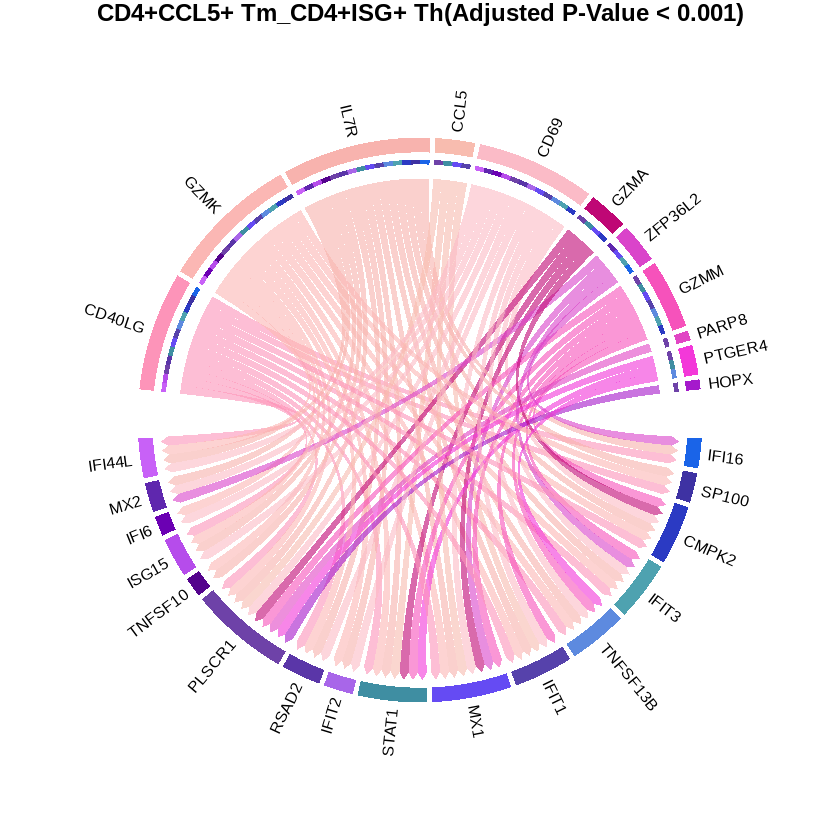

In [ ]:
# `select` the cell-cell interaction #3 according to the index

# Default `color`

TimiGeneChord(resdata = res,select = 3, color = NULL)

# Save as SVG
svg("cell_cell_interaction_1_Top5percent.svg", width = 10, height = 10)
TimiGeneChord(resdata = res, select = 1, color = NULL)
dev.off()

# Save as TIFF with 300 dpi
tiff("cell_cell_interaction_1_Top5percent.tiff", width = 10, height = 10, units = "in", res = 300)
TimiGeneChord(resdata = res, select = 1, color = NULL)
dev.off()

# Save as SVG
svg("cell_cell_interaction_2_Top5percent.svg", width = 10, height = 10)
TimiGeneChord(resdata = res, select = 2, color = NULL)
dev.off()

# Save as TIFF with 300 dpi
tiff("cell_cell_interaction_2_Top5percent.tiff", width = 10, height = 10, units = "in", res = 300)
TimiGeneChord(resdata = res, select = 2, color = NULL)
dev.off()

# Save as SVG
svg("cell_cell_interaction_3_Top5percent.svg", width = 10, height = 10)
TimiGeneChord(resdata = res, select = 3, color = NULL)
dev.off()

# Save as TIFF with 300 dpi
tiff("cell_cell_interaction_3_Top5percent.tiff", width = 10, height = 10, units = "in", res = 300)
TimiGeneChord(resdata = res, select = 3, color = NULL)
dev.off()

# Save as SVG
svg("cell_cell_interaction_4_Top5percent.svg", width = 10, height = 10)
TimiGeneChord(resdata = res, select = 4, color = NULL)
dev.off()

# Save as TIFF with 300 dpi
tiff("cell_cell_interaction_4_Top5percent.tiff", width = 10, height = 10, units = "in", res = 300)
TimiGeneChord(resdata = res, select = 4, color = NULL)
dev.off()

# Save as SVG
svg("cell_cell_interaction_5_Top5percent.svg", width = 10, height = 10)
TimiGeneChord(resdata = res, select = 5, color = NULL)
dev.off()

# Save as TIFF with 300 dpi
tiff("cell_cell_interaction_5_Top5percent.tiff", width = 10, height = 10, units = "in", res = 300)
TimiGeneChord(resdata = res, select = 5, color = NULL)
dev.off()

Using cell-cell interactions(Adjust.P.Value < 0.05)



pdf 
  2

pdf 
  2

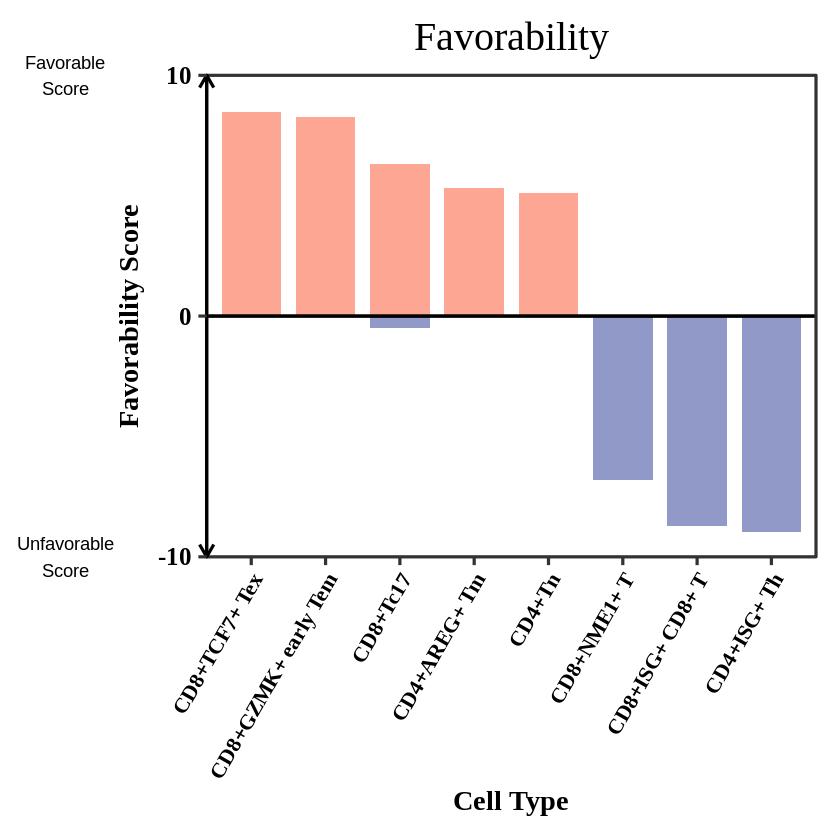

In [ ]:
# Run TimiFS
score <- TimiFS(resdata = res,
                condition = CIcondition,
                cutoff = CIcutoff)
write.csv(score, file = 'score.csv')

# Visualize favorability scores for selected cell types,

# including the top 5 and bottom 3 cell types.

TimiFSBar(score, select = c(1:5, (nrow(score) - 2):nrow(score)))

# Save as SVG
svg("TimiFSBar_output_Top5percent.svg", width = 12, height = 8)
TimiFSBar(score, select = c(1:5, (nrow(score) - 2):nrow(score)))
dev.off()

# Save as TIFF with 300 dpi
tiff("TimiFSBar_output_Top5percent.tiff", width = 12, height = 8, units = "in", res = 300)
TimiFSBar(score, select = c(1:5, (nrow(score) - 2):nrow(score)))
dev.off()

In [ ]:
# Define A4 dimensions in inches
a4_width <- 25
a4_height <- 25

# Function to export TimiCellChord to various formats
export_timicellchord <- function(filename, width, height, res = 300, ...) {
  # Determine file format based on extension
  format <- tools::file_ext(filename)

  # Open appropriate device based on format
  switch(format,
         "pdf" = pdf(filename, width = width, height = height),
         "tiff" = tiff(filename, width = width, height = height, units = "in", res = res),
         "svg" = svg(filename, width = width, height = height),
         stop("Unsupported file format. Use pdf, tiff, or svg."))

  # Create the plot directly to the device
  TimiCellChord(...)

  # Close the device
  dev.off()

  print(paste("TimiCellChord plot saved to", filename))
}

# Export TimiCellChord plot to PDF, TIFF, and SVG (Portrait)
for (format in c("pdf", "tiff", "svg")) {
  export_timicellchord(
    paste0("TimiCellChord_A4_portrait_Top5percent.", format),
    a4_height,
    a4_width,
    resdata = res,
    select = NULL,
    dataset = "Zheng2021",
    group = NULL,
    color = NULL,
    condition = CIcondition,
    cutoff = CIcutoff
  )
}

# Export TimiCellChord plot to PDF, TIFF, and SVG (Landscape)
for (format in c("pdf", "tiff", "svg")) {
  export_timicellchord(
    paste0("TimiCellChord_A4_landscape_Top5percent.", format),
    a4_height,
    a4_width,
    resdata = res,
    select = NULL,
    dataset = "Zheng2021",
    group = NULL,
    color = NULL,
    condition = CIcondition,
    cutoff = CIcutoff
  )
}

Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_portrait_Top5percent.pdf"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_portrait_Top5percent.tiff"


Using cell-cell interactions(Adjust.P.Value < 0.05)



...

[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.pdf"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.tiff"


Using cell-cell interactions(Adjust.P.Value < 0.05)



[1] "TimiCellChord plot saved to TimiCellChord_A4_landscape_Top5percent.svg"


# Save everything as R session

In [ ]:
# Save the entire workspace to a file named 'workspace.RData'
save.image(file = "timi_normla_weight_Bindea2013.RData")